# CC3092 – Deep Learning · Laboratorio 7
## Forecasting de temperatura de aceite (ETTh1) con LSTM y Transformer implementados desde cero
**Entrega parcial: Task 1 y Task 2**

**Entrega final: Todo**

## Task 1.1 – Descarga y preprocesamiento

In [1]:
import urllib.request
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)
print("Longitud de la serie:", len(OT))

Dispositivo: cpu
Longitud de la serie: 17420


### a) y b) Normalización z-score y split temporal 60/20/20

Normalización: $z_t = \dfrac{x_t - \mu}{\sigma}$. Para desnormalizar: $x_t = z_t\,\sigma + \mu$.

$\mu$ y $\sigma$ se calculan solo con el bloque de entrenamiento, para no filtrar información del futuro (validación/prueba) al modelo. Luego se aplica la misma transformación a toda la serie.

In [2]:
N_total = len(OT)
n_train = int(0.6 * N_total)          # índice donde termina train
n_val   = int(0.8 * N_total)          # índice donde termina val

# mu y sigma calculados solo sobre el bloque de entrenamiento 
mu    = float(OT[:n_train].mean())
sigma = float(OT[:n_train].std())

# z_t = (x_t - mu) / sigma
OT_norm = torch.tensor((OT - mu) / sigma, dtype=torch.float32)

# Bloques contiguos, sin mezcla aleatoria: [0, n_train) | [n_train, n_val) | [n_val, N)
OT_train = OT_norm[:n_train]
OT_val   = OT_norm[n_train:n_val]
OT_test  = OT_norm[n_val:]

def denorm(z):
    """x_t = z_t * sigma + mu"""
    return z * sigma + mu

print(f"mu = {mu:.4f} °C, sigma = {sigma:.4f} °C")
print(f"train: {len(OT_train)}, val: {len(OT_val)}, test: {len(OT_test)}")

mu = 17.2925 °C, sigma = 8.5137 °C
train: 10452, val: 3484, test: 3484


### c) Ventanas deslizantes

Para cada instante $t$: $X^{(t)} = (x_{t-L+1},\dots,x_t)$ y $y^{(t)} = x_{t+H}$.

Si la serie tiene $T$ puntos, el primer $t$ válido es $t=L-1$ y el último es $t=T-1-H$, por lo que $N = T - L - H + 1$ ejemplos. Cada split se ventanea por separado, así ninguna ventana cruza la frontera entre conjuntos.

In [3]:
def make_windows(series, L, H):
    """
    series : tensor 1D (T,)
    Retorna X (N, L) y y (N,) con
        X[j] = (x_{t-L+1}, ..., x_t),   y[j] = x_{t+H},   t = j + L - 1
    """
    series = torch.as_tensor(series, dtype=torch.float32)
    T = series.shape[0]
    N = T - L - H + 1
    # unfold genera todas las ventanas de tamaño L con paso 1: (T-L+1, L)
    X = series.unfold(0, L, 1)[:N]
    # el objetivo de la ventana j (que termina en t = j+L-1) es x_{t+H}
    y = series[L - 1 + H : L - 1 + H + N]
    return X.contiguous(), y.contiguous()

L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L, 24)
X_te_24, y_te_24 = make_windows(OT_test,  L, 24)

X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L, 48)
X_te_48, y_te_48 = make_windows(OT_test,  L, 48)

for name, X, y in [("tr_24", X_tr_24, y_tr_24), ("vl_24", X_vl_24, y_vl_24),
                   ("tr_48", X_tr_48, y_tr_48), ("vl_48", X_vl_48, y_vl_48)]:
    print(f"X_{name}: {tuple(X.shape)}  y_{name}: {tuple(y.shape)}")

# Chequeo puntual de la definición: y[0] debe ser x_{(L-1)+H}
assert torch.equal(y_tr_24[0], OT_train[L - 1 + 24])
assert torch.equal(X_tr_24[5], OT_train[5:5 + L])

X_tr_24: (10333, 96)  y_tr_24: (10333,)
X_vl_24: (3365, 96)  y_vl_24: (3365,)
X_tr_48: (10309, 96)  y_tr_48: (10309,)
X_vl_48: (3341, 96)  y_vl_48: (3341,)


## Task 1.2 – Función de autocorrelación (ACF)

$$\rho(k)=\frac{\frac{1}{N-k}\sum_{t=k}^{N-1}(x_t-\bar x)(x_{t-k}-\bar x)}{\frac{1}{N}\sum_{t=0}^{N-1}(x_t-\bar x)^2}$$

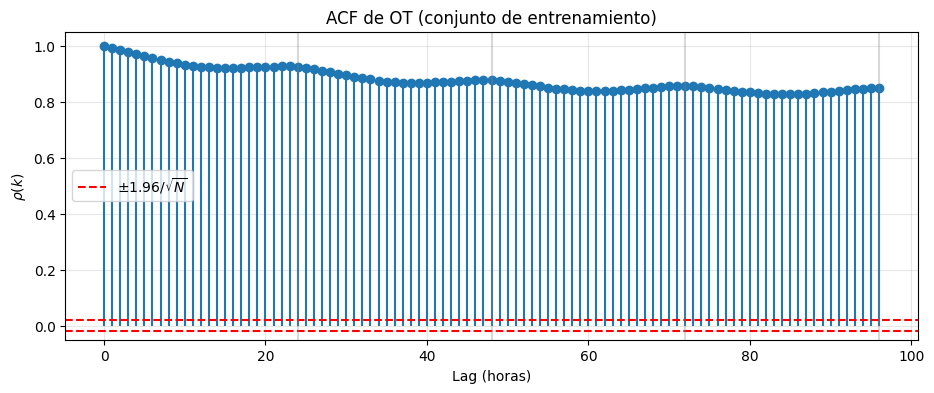

Banda de confianza 95%: ±0.0192
rho( 1) = 0.9923
rho( 6) = 0.9558
rho(12) = 0.9250
rho(22) = 0.9262
rho(24) = 0.9250
rho(36) = 0.8695
rho(47) = 0.8770
rho(48) = 0.8763
rho(72) = 0.8572
rho(84) = 0.8266
rho(96) = 0.8489
Picos locales: [(22, np.float64(0.9262)), (47, np.float64(0.877)), (72, np.float64(0.8572))]


In [4]:
def acf_manual(series, max_lag):
    """ACF para lags 0..max_lag según la fórmula del enunciado."""
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    xc = x - x.mean()                         # (x_t - x̄)
    denom = np.sum(xc ** 2) / N               # (1/N) Σ (x_t - x̄)^2  -> varianza
    rho = np.empty(max_lag + 1)
    for k in range(max_lag + 1):
        # Σ_{t=k}^{N-1} (x_t - x̄)(x_{t-k} - x̄), normalizado por (N-k)
        num = np.sum(xc[k:] * xc[:N - k]) / (N - k)
        rho[k] = num / denom
    return rho

acf_tr = acf_manual(OT_train.numpy(), 96)
conf = 1.96 / np.sqrt(len(OT_train))      # banda de confianza al 95%

plt.figure(figsize=(11, 4))
plt.stem(range(len(acf_tr)), acf_tr, basefmt=" ")
plt.axhline( conf, color="r", ls="--", label=r"$\pm 1.96/\sqrt{N}$")
plt.axhline(-conf, color="r", ls="--")
for k in (24, 48, 72, 96):
    plt.axvline(k, color="gray", alpha=0.3)
plt.xlabel("Lag (horas)"); plt.ylabel(r"$\rho(k)$")
plt.title("ACF de OT (conjunto de entrenamiento)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"Banda de confianza 95%: ±{conf:.4f}")
for k in (1, 6, 12, 22, 24, 36, 47, 48, 72, 84, 96):
    print(f"rho({k:2d}) = {acf_tr[k]:.4f}")

# Picos locales (máximos relativos) después del lag 0
peaks = [k for k in range(2, 96) if acf_tr[k] > acf_tr[k-1] and acf_tr[k] > acf_tr[k+1]]
print("Picos locales:", [(k, round(acf_tr[k], 4)) for k in peaks])

### Interpretación (a) – segundo pico de la ACF

La ACF decae monótonamente desde $\rho(1)\approx0.992$ hasta un valle cerca de lag 12–18 y vuelve a subir, formando el primer máximo local alrededor de lag 22–24 ($\rho(22)\approx0.926$, $\rho(24)\approx0.925$). Los siguientes picos aparecen en lag ≈47 ($0.877$) y ≈72 ($0.857$), separados ~24 h entre sí. Esto indica un ciclo diario. La temperatura del aceite sigue el patrón de carga eléctrica (mayor consumo de día, menor de noche), y la del mismo horario del día anterior es el mejor predictor tras las horas inmediatamente previas. Que el máximo quede en 22 en vez de exactamente 24 se debe a que la curva es muy plana en esa zona (diferencia ≈0.001).

### Justificación (b) – ¿es adecuado L = 96?

- Todos los lags 1–96 están muy por encima de la banda ±0.019, es decir, la serie es muy persistente (tendencia/estacionalidad lenta) y hay información útil en toda la ventana.
- Con $L=96$ la ventana contiene cuatro ciclos diarios completos (picos en 24, 48, 72 y 96), lo que permite al modelo ver varias repeticiones del patrón diario y promediar el ruido de un solo día.
- Los picos decaen lentamente ($0.925 \to 0.877 \to 0.857 \to 0.849$ en lag 96): un día más de historia aporta cada vez menos correlación marginal, y alargar la ventana encarece el LSTM (más pasos secuenciales, gradientes que viajan más lejos) con poco beneficio.
- Una ventana menor a 24 perdería el ciclo diario completo; una de 24–48 captaría solo 1–2 ciclos.

Conclusión: $L=96$ es una elección razonable, aunque podría reducirse a ~48–72 sin perder el patrón diario, pero esto no conviene hacerla mucho mayor dado el decaimiento lento de los picos.

## Verificación Task 1

In [5]:
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.2009)


## Task 2.1 – LSTM implementado manualmente

Ecuaciones de la celda en cada paso $t$:

$$\begin{aligned}
[\tilde i,\tilde f,\tilde g,\tilde o] &= x_t W_x^\top + h_{t-1} W_h^\top + b\\
i_t=\sigma(\tilde i),\quad f_t&=\sigma(\tilde f),\quad g_t=\tanh(\tilde g),\quad o_t=\sigma(\tilde o)\\
c_t &= f_t\odot c_{t-1} + i_t\odot g_t\\
h_t &= o_t\odot\tanh(c_t)\\
\hat y &= h_L W_{out}^\top + b_{out}
\end{aligned}$$

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        k = 1.0 / math.sqrt(d_h)   # misma escala de inicialización que usa PyTorch
        # Pesos de las 4 compuertas apilados en el orden [i, f, g, o]
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in).uniform_(-k, k))  # (4*d_h, d_in)
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h).uniform_(-k, k))   # (4*d_h, d_h)
        b = torch.zeros(4 * d_h)
        b[d_h:2 * d_h] = 1.0   # sesgo de la compuerta de olvido = 1: al inicio f≈0.73,
                               # la celda "recuerda" y el gradiente fluye mejor por c_t
        self.b = nn.Parameter(b)                                            # (4*d_h,)
        # Capa de salida: h_L -> escalar
        self.W_out = nn.Parameter(torch.empty(1, d_h).uniform_(-k, k))      # (1, d_h)
        self.b_out = nn.Parameter(torch.zeros(1))                           # (1,)

    def forward(self, x):
        """
        x    : Tensor (B, L) batch de secuencias univariadas
        pred : Tensor (B,)   predicción escalar por secuencia
        """
        B, L = x.shape
        x = x.reshape(B, L, 1)                                   # 1. (B, L, d_in=1)
        h = torch.zeros(B, self.d_h, device=x.device, dtype=x.dtype)   # 2. h_0 = 0
        c = torch.zeros(B, self.d_h, device=x.device, dtype=x.dtype)   #    c_0 = 0

        for t in range(L):                                       # 3. recurrencia
            # a. preactivaciones de las 4 compuertas: x_t Wx^T + h_{t-1} Wh^T + b
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b      # (B, 4*d_h)
            # b. separar en bloques de tamaño d_h
            i, f, g, o = gates.chunk(4, dim=1)
            # c. no linealidades
            i = torch.sigmoid(i)      # compuerta de entrada
            f = torch.sigmoid(f)      # compuerta de olvido
            g = torch.tanh(g)         # candidato a memoria
            o = torch.sigmoid(o)      # compuerta de salida
            # d. c_t = f ⊙ c_{t-1} + i ⊙ g
            c = f * c + i * g
            # e. h_t = o ⊙ tanh(c_t)
            h = o * torch.tanh(c)

        pred = h @ self.W_out.T + self.b_out                     # 4. (B, 1)
        return pred.squeeze(-1)                                  # 5. (B,)

## Task 2.2 – Entrenamiento

**Función de pérdida:** MSE, $\mathcal L = \frac1N\sum (y-\hat y)^2$. Ver justificación en las preguntas de análisis.

### Diagnóstico: cambio de distribución entre train y validación

Con la formulación directa (predecir el nivel absoluto $x_{t+H}$), el LSTM alcanzó MSE de entrenamiento $\approx0.120$, menor que el naive en train ($\approx0.152$). Sin embargo, en validación obtuvo ratio $\approx1.28$ (peor que el naive).

La celda siguiente muestra la causa: el bloque de entrenamiento (primeros 60%, meses cálidos) tiene media normalizada $0$, mientras que validación está desplazada $\approx-1.2\sigma$ (más fría). El LSTM, con activaciones saturables ($\sigma$, $\tanh$) y un sesgo $b_{out}$ ajustado a train, sesga sus predicciones hacia los niveles de train. El naive $\hat y=x_t$ no sufre este problema porque sigue el nivel actual.

Solución: aprendizaje residual (invariante al nivel). A cada ventana se le resta su último valor $x_t$:

$$\tilde X^{(t)} = X^{(t)} - x_t,\qquad \tilde y^{(t)} = x_{t+H} - x_t,\qquad \hat y^{(t)} = x_t + \text{LSTM}(\tilde X^{(t)})$$

El modelo aprende el *cambio* en las próximas $H$ horas en vez del nivel absoluto, así que un desplazamiento global de la serie no lo afecta. Si la red predice $0$, se recupera exactamente el naive, por lo que el baseline queda como punto de partida. La clase `LSTMForecaster` no cambia; solo cambia qué se le da como entrada y cómo se interpreta su salida.

train: media z = +0.000  min = -2.51  max = +3.37  (media en °C = 17.29)
val  : media z = -1.206  min = -2.47  max = +0.27  (media en °C = 7.02)
test : media z = -1.124  min = -2.14  max = -0.01  (media en °C = 7.72)


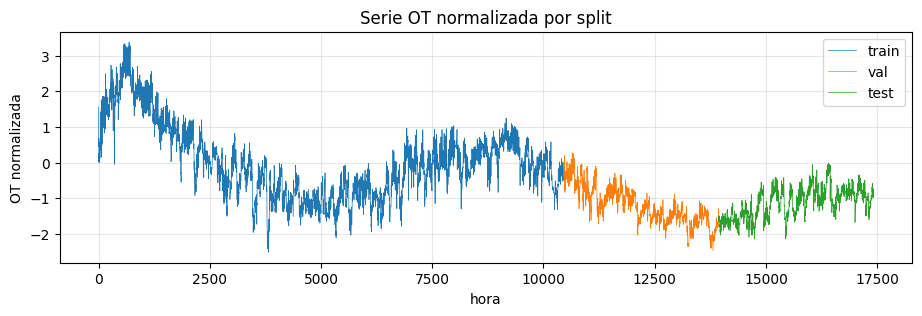

In [7]:
# Diagnóstico del cambio de nivel entre splits
for name, s in [("train", OT_train), ("val", OT_val), ("test", OT_test)]:
    print(f"{name:5s}: media z = {s.mean().item():+.3f}  min = {s.min().item():+.2f}  max = {s.max().item():+.2f}"
          f"  (media en °C = {denorm(s.mean().item()):.2f})")

plt.figure(figsize=(11, 3))
plt.plot(range(n_train), OT_train, lw=0.5, label="train")
plt.plot(range(n_train, n_val), OT_val, lw=0.5, label="val")
plt.plot(range(n_val, N_total), OT_test, lw=0.5, label="test")
plt.ylabel("OT normalizada"); plt.xlabel("hora"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Serie OT normalizada por split"); plt.show()


In [8]:
def to_residual(X):
    """X̃ = X - x_t : la ventana relativa a su último valor. Devuelve (X̃, x_t)."""
    last = X[:, -1]
    return X - last.unsqueeze(1), last

def train_model(model, X, y, epochs=20, batch_size=64, lr=1e-3, clip=1.0, seed=42):
    """Entrena con Adam + MSE sobre el objetivo residual ỹ = x_{t+H} - x_t.
    Devuelve la pérdida media por época."""
    torch.manual_seed(seed)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    X_rel, last = to_residual(X)
    y_rel = y - last                              # ỹ = x_{t+H} - x_t
    X_rel, y_rel = X_rel.to(device), y_rel.to(device)
    n = X_rel.shape[0]
    history = []
    for ep in range(epochs):
        model.train()
        # Se barajan las VENTANAS de train (no la serie): cada ventana conserva
        # su orden temporal interno, así que no hay fuga de información.
        perm = torch.randperm(n, device=device)
        total = 0.0
        for s in range(0, n, batch_size):
            idx = perm[s:s + batch_size]
            pred = model(X_rel[idx])
            # MSE sobre el residual; como ŷ - y = (x_t + pred) - (x_t + ỹ) = pred - ỹ,
            # es exactamente el MSE sobre la predicción final.
            loss = F.mse_loss(pred, y_rel[idx])
            opt.zero_grad()
            loss.backward()                          # BPTT a través de los L pasos
            # Recorte de norma del gradiente: evita explosión en la BPTT
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            total += loss.item() * len(idx)
        history.append(total / n)
        print(f"  época {ep+1:2d}/{epochs}  loss_train={history[-1]:.5f}")
    return history

@torch.no_grad()
def predict(model, X, batch_size=512):
    """ŷ = x_t + LSTM(X - x_t): se devuelve la predicción en la escala normalizada original."""
    model.eval()
    X_rel, last = to_residual(X)
    out = [model(X_rel[s:s + batch_size].to(device)).cpu() for s in range(0, len(X), batch_size)]
    return last + torch.cat(out)

def metrics(y, pred, X):
    """MAE, RMSE (en unidades normalizadas y en °C) y ratio vs naive (ŷ = x_t)."""
    mae  = torch.abs(y - pred).mean().item()
    rmse = torch.sqrt(((y - pred) ** 2).mean()).item()
    naive = torch.abs(y - X[:, -1]).mean().item()
    return {"MAE": mae, "RMSE": rmse, "MAE_°C": mae * sigma, "RMSE_°C": rmse * sigma,
            "naive_MAE": naive, "ratio": mae / naive}


In [9]:
print("Entrenando LSTM H=24")
lstm_24 = LSTMForecaster(d_in=1, d_h=32)
hist_lstm_24 = train_model(lstm_24, X_tr_24, y_tr_24)

print("\nEntrenando LSTM H=48")
lstm_48 = LSTMForecaster(d_in=1, d_h=32)
hist_lstm_48 = train_model(lstm_48, X_tr_48, y_tr_48)

Entrenando LSTM H=24
  época  1/20  loss_train=0.14373
  época  2/20  loss_train=0.13784
  época  3/20  loss_train=0.13667
  época  4/20  loss_train=0.13518
  época  5/20  loss_train=0.13467
  época  6/20  loss_train=0.13362
  época  7/20  loss_train=0.13277
  época  8/20  loss_train=0.13477
  época  9/20  loss_train=0.13304
  época 10/20  loss_train=0.13317
  época 11/20  loss_train=0.13233
  época 12/20  loss_train=0.13237
  época 13/20  loss_train=0.13219
  época 14/20  loss_train=0.13187
  época 15/20  loss_train=0.13179
  época 16/20  loss_train=0.13059
  época 17/20  loss_train=0.13086
  época 18/20  loss_train=0.13081
  época 19/20  loss_train=0.13120
  época 20/20  loss_train=0.13066

Entrenando LSTM H=48
  época  1/20  loss_train=0.22355
  época  2/20  loss_train=0.21007
  época  3/20  loss_train=0.20383
  época  4/20  loss_train=0.20221
  época  5/20  loss_train=0.20258
  época  6/20  loss_train=0.20229
  época  7/20  loss_train=0.20018
  época  8/20  loss_train=0.19979
  épo

In [10]:
pred_vl_24 = predict(lstm_24, X_vl_24)
pred_vl_48 = predict(lstm_48, X_vl_48)

res_lstm_24 = metrics(y_vl_24, pred_vl_24, X_vl_24)
res_lstm_48 = metrics(y_vl_48, pred_vl_48, X_vl_48)

print(f"{'Modelo':<12}{'H':>4}{'MAE':>9}{'RMSE':>9}{'MAE °C':>9}{'RMSE °C':>9}{'ratio':>8}")
for name, H, r in [("LSTM", 24, res_lstm_24), ("LSTM", 48, res_lstm_48)]:
    print(f"{name:<12}{H:>4}{r['MAE']:>9.4f}{r['RMSE']:>9.4f}{r['MAE_°C']:>9.3f}{r['RMSE_°C']:>9.3f}{r['ratio']:>8.3f}")
for H, X, y in [(24, X_vl_24, y_vl_24), (48, X_vl_48, y_vl_48)]:
    naive = X[:, -1]
    mae = torch.abs(y - naive).mean().item(); rmse = torch.sqrt(((y - naive) ** 2).mean()).item()
    print(f"{'Naive':<12}{H:>4}{mae:>9.4f}{rmse:>9.4f}{mae*sigma:>9.3f}{rmse*sigma:>9.3f}{1.0:>8.3f}")

Modelo         H      MAE     RMSE   MAE °C  RMSE °C   ratio
LSTM          24   0.2048   0.2578    1.744    2.195   1.020
LSTM          48   0.2500   0.3105    2.128    2.643   0.954
Naive         24   0.2009   0.2689    1.710    2.289   1.000
Naive         48   0.2620   0.3380    2.231    2.878   1.000


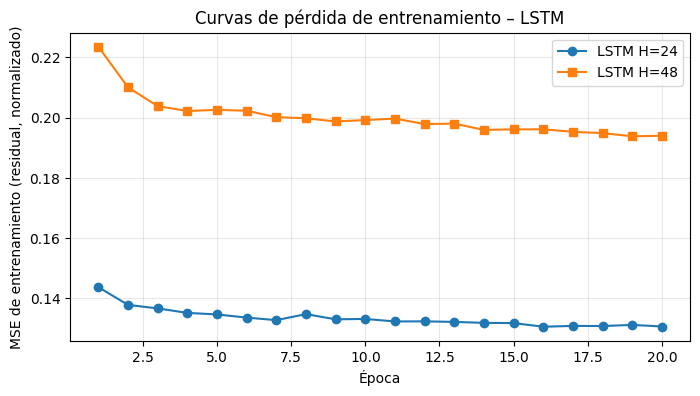

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), hist_lstm_24, "o-", label="LSTM H=24")
plt.plot(range(1, 21), hist_lstm_48, "s-", label="LSTM H=48")
plt.xlabel("Época"); plt.ylabel("MSE de entrenamiento (residual, normalizado)")
plt.title("Curvas de pérdida de entrenamiento – LSTM")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Verificación Task 2

In [12]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"

print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
  LSTM H=24: MAE=0.2048, ratio=1.020
